In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets

fake_df = pd.read_csv("../data/raw/Fake.csv")
true_df = pd.read_csv("../data/raw/True.csv")

In [3]:
# Display the first 5 rows

fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
# Shape of the datasets

print("Fake News Dataset Shape:", fake_df.shape)
print("True News Dataset Shape:", true_df.shape)

Fake News Dataset Shape: (23481, 4)
True News Dataset Shape: (21417, 4)


In [6]:
fake_df.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [7]:
true_df.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [8]:
fake_df.dtypes

title      str
text       str
subject    str
date       str
dtype: object

In [9]:
true_df.dtypes

title      str
text       str
subject    str
date       str
dtype: object

In [10]:
fake_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


In [11]:
true_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


In [12]:
fake_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [13]:
true_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [14]:
fake_df.duplicated().sum()

np.int64(3)

In [15]:
true_df.duplicated().sum()

np.int64(206)

In [16]:
# Remove duplicate rows

fake_df = fake_df.drop_duplicates()
true_df = true_df.drop_duplicates()

In [17]:
print(fake_df.duplicated().sum())
print(true_df.duplicated().sum())

0
0


In [18]:
# Add labels

fake_df["label"] = 0
true_df["label"] = 1

In [19]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [20]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [21]:
# Combine both datasets

news_df = pd.concat([fake_df, true_df], ignore_index=True)

In [22]:
news_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [23]:
news_df.tail()

,title,text,subject,date,label
44684,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44685,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44686,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44687,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
44688,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [24]:
print(news_df.shape)

(44689, 5)


In [ ]:
#suffle the dataset
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
#Verify the suffle
news_df.head(10)

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0
5,Trump’s Longtime Friend Larry King Just STUNG...,Larry King has been in the radio and journalis...,News,"April 4, 2017",0
6,NAFTA talks must include discussion on fintech...,WASHINGTON (Reuters) - Talks to renegotiate th...,politicsNews,"August 17, 2017",1
7,Putin-linked think tank drew up plan to sway 2...,WASHINGTON (Reuters) - A Russian government th...,politicsNews,"April 19, 2017",1
8,"Exclusive: McConnell frets about healthcare, h...",WASHINGTON (Reuters) - U.S. Senate Majority Le...,politicsNews,"May 24, 2017",1
9,U.S. to withdraw from U.N.'s cultural agency i...,WASHINGTON (Reuters) - The United States is wi...,worldnews,"October 12, 2017",1


In [27]:
# Count the number of Fake and True news articles

news_df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

C:\Users\ankita\AppData\Local\Temp\ipykernel_23876\2444791565.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


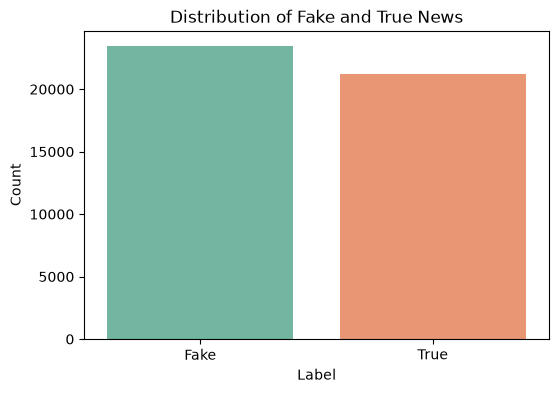

In [28]:
# Plot the distribution of Fake and True news

plt.figure(figsize=(6,4))

sns.countplot(
    data=news_df,
    x="label",
    palette="Set2"
)

plt.title("Distribution of Fake and True News")

plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=["Fake","True"]
)

plt.show()

In [ ]:
# Check news category
news_df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

C:\Users\ankita\AppData\Local\Temp\ipykernel_23876\2523120859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


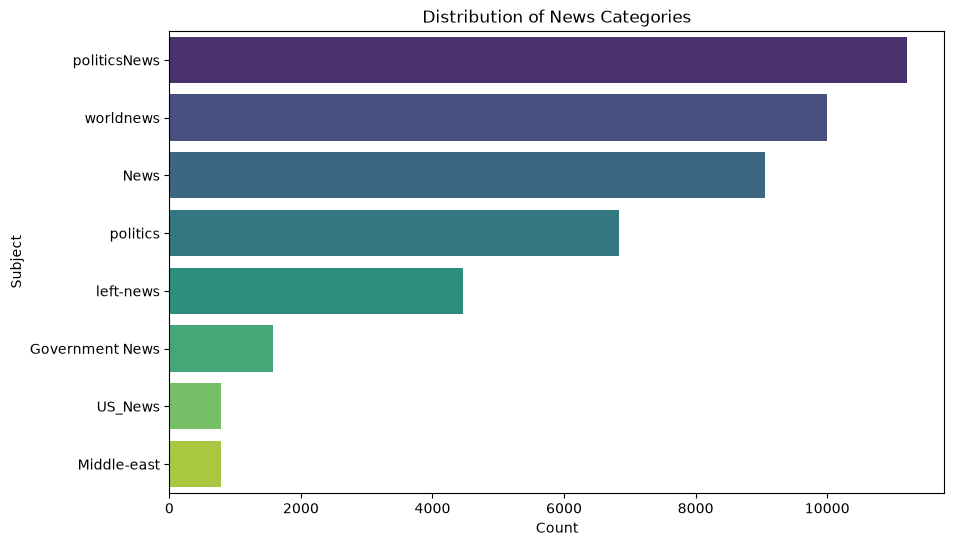

In [30]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=news_df,
    y="subject",
    order=news_df["subject"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of News Categories")

plt.xlabel("Count")
plt.ylabel("Subject")

plt.show()

In [31]:
# Calculate article length

news_df["text_length"] = news_df["text"].apply(len)

news_df["text_length"].head()

0    10062
1     2808
2      232
3      610
4     2658
Name: text_length, dtype: int64

In [32]:
# get statistics
news_df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

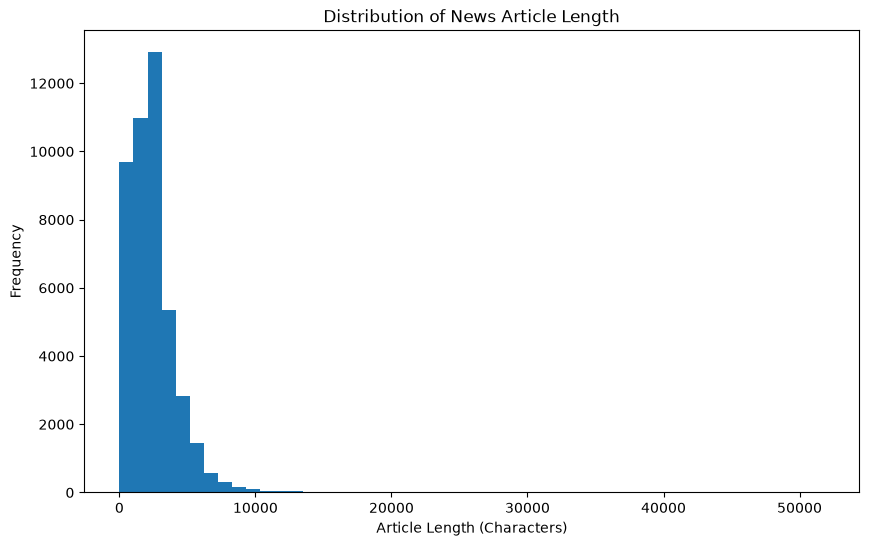

In [33]:
plt.figure(figsize=(10,6))

plt.hist(news_df["text_length"], bins=50)

plt.title("Distribution of News Article Length")

plt.xlabel("Article Length (Characters)")
plt.ylabel("Frequency")

plt.show()

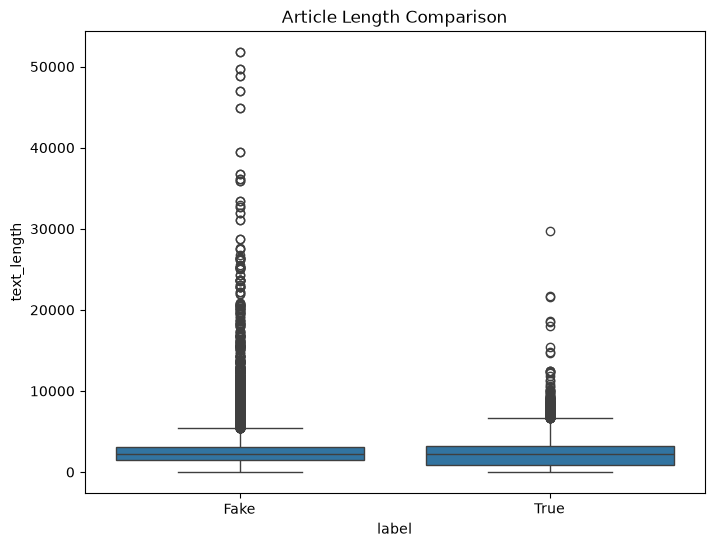

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=news_df,
    x="label",
    y="text_length"
)

plt.xticks([0,1],["Fake","True"])

plt.title("Article Length Comparison")

plt.show()

In [35]:
news_df.to_csv("../data/processed/clean_news.csv", index=False)